In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

In [2]:
# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

In [3]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d.frank2d import Frank2D 
from frank2d.geometry import Geometry
from frank2d.constants import rad_to_arcsec
from frank2d.plot import Plot
from frank2d.fitting import IterativeSolverMethod

In [4]:
from scipy.special import j0
from scipy.stats import binned_statistic

In [5]:
from scipy.optimize import curve_fit

### Functions

In [6]:
def gauss(r, sigma):
    return np.exp(-0.5*((r-rout/2.)/sigma)**2)

### Load data

In [7]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}

In [8]:
data = AS209

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j


uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}


In [9]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [10]:
geom_f2d = Geometry(inc, pa, dra, ddec)
geom_Ring = geom_f2d

In [11]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 772
Rmax = 3.5999999999999996


### Create the ring in uv-space

In [12]:
# Deprojection
du, dv, _ = geom_f2d.deproject(u, v)
dbaseline = np.hypot(du, dv)

baseline = np.hypot(u, v)

In [13]:
baseline_ring = baseline
u_ring = u
v_ring = v

In [96]:
Re_ring = np.median(Re[np.where(baseline_ring<1e5)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2)*baseline_ring))

In [97]:
Imag_ring = np.zeros(len(Re))
Vis_ring = Re_ring + Imag_ring*1j

In [98]:
uvtable = {'u': u_ring, 'v': v_ring, 'vis': Vis_ring, 'weights': Weights}


### Frank2D

In [99]:
N

772

In [100]:
frank2d = Frank2D(N, Rmax)

In [101]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [102]:
best_N50 = {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266}
best = best_N50

In [103]:
frank2d.fit(kernel_params = best, rtol = 1e-10)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266}
===>  Creating sparse linear system...


        +  Kernel = 0.05  min |  2.78 seconds
        +  Building system = 0.05  min |  2.85 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 152/50000 [00:14<1:17:00, 10.79 iterations/s]


            +  BiCGStab = 0.23  min |  14.09 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.01651622824663949,
 'iterations': 152,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.16  min |  9.78 seconds
--> times building full visibility model = 0.16  min |  9.82 seconds


In [104]:
Plot_ = Plot(frank2d, geom_Ring)

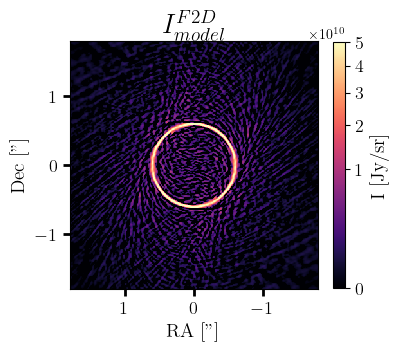

In [105]:
Plot_.intensity(vmax = 5e10, zoom = 2, fig_size=4)

### Best

In [106]:
PlotRing = Plot(frank2d, geom_Ring)

In [107]:
m = -1
p = -2.1
c = 10**(p -  5*m)
c

794.3282347242813

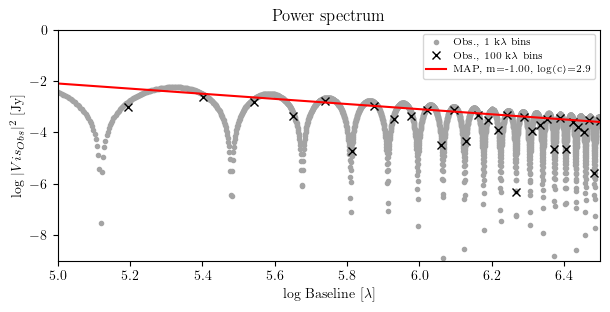

In [108]:
PlotRing.power_spectrum(uvtable, m = m, c =c)

In [109]:
frank2d.search_MAP(initial_guess={'m': m, 'p': p, 'logl': 4})

Using existing visibility data...
===>  Searching for MAP...
        + Initial guess:  {'m': -1, 'p': -2.1, 'logl': 4}
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 421.36 seconds
Setting the initial guess...
Optimizing the posterior...
 + Time to optimize the posterior: 763.17 seconds


In [118]:
best = frank2d.MAP
best

{'m': -0.6452370154476217, 'c': 1.490623032073248, 'l': 41674.1248467192}

### Run a new Frank2D Object

In [119]:
best = {'m': -0.6452370154476217, 'c': 1.490623032073248, 'l': 41674.1248467192}

In [120]:
frank2d2 = Frank2D(N, Rmax)

In [121]:
frank2d2.fit(data = uvtable, kernel_params = best, rtol = 1e-10)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -0.6452370154476217, 'c': 1.490623032073248, 'l': 41674.1248467192}
===>  Creating sparse linear system...
        +  Kernel = 0.10  min |  5.78 seconds
        +  Building system = 0.10  min |  5.90 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 190/50000 [00:23<1:40:53,  8.23 iterations/s]


            +  BiCGStab = 0.38  min |  23.09 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.01651622824663949,
 'iterations': 190,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.19  min |  11.55 seconds
--> times building full visibility model = 0.19  min |  11.60 seconds


### Plot

In [122]:
Plot_ = Plot(frank2d, geom_Ring)

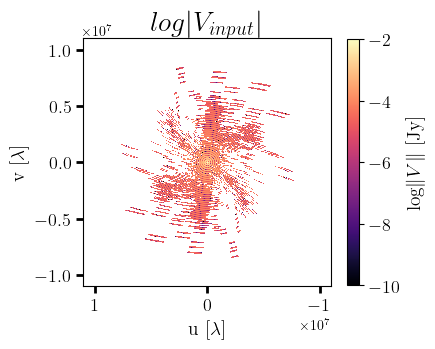

In [123]:
Plot_.visibility(fig_size = 4, kind = 'input',  title= r'$log|V_{input}|$')

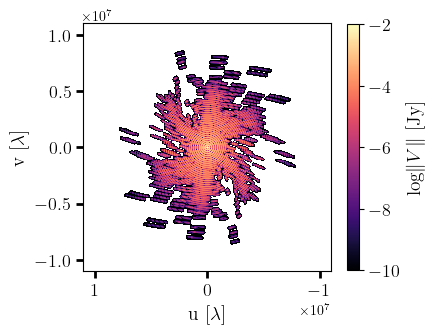

In [124]:
Plot_.visibility(fig_size = 4, title= r'')

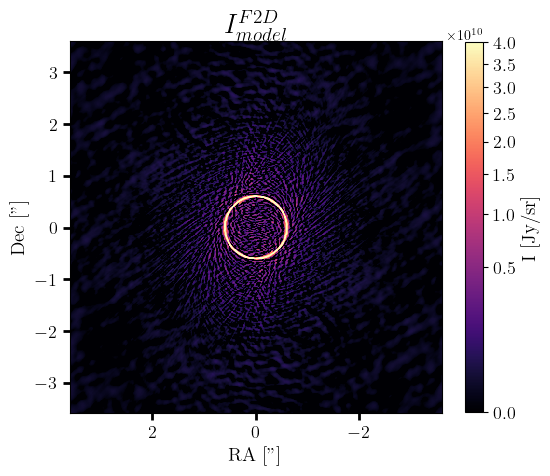

In [125]:
Plot_.intensity(fig_size = 6)

### Try with different N's

In [126]:
#Ns = [ceil(0.5*N), ceil(N), ceil(1.25*N), ceil(1.5*N), ceil(1.75*N), ceil(2*N), ceil(2.5*N), ceil(3*N)]

In [127]:
Ns = [N]

In [128]:
resolutions = []
resolutions_error = []

In [129]:
frank2d_objs = []

In [130]:
for N in Ns:
    print("xxxxxxxxxxxxxxxxxxxxxx N =", N, " xxxxxxxxxxxxxxxxxxxxxx")
    frank2d2 = Frank2D(N, Rmax)
    frank2d2.fit( data = uvtable, kernel_params = best, rtol = 1e-10)
    frank2d_objs.append(frank2d2)


xxxxxxxxxxxxxxxxxxxxxx N = 772  xxxxxxxxxxxxxxxxxxxxxx


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -0.6452370154476217, 'c': 1.490623032073248, 'l': 41674.1248467192}
===>  Creating sparse linear system...
        +  Kernel = 0.10  min |  5.79 seconds
        +  Building system = 0.10  min |  5.91 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 190/50000 [00:21<1:35:08,  8.73 iterations/s]


            +  BiCGStab = 0.36  min |  21.78 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.01651622824663949,
 'iterations': 190,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.19  min |  11.57 seconds
--> times building full visibility model = 0.19  min |  11.62 seconds


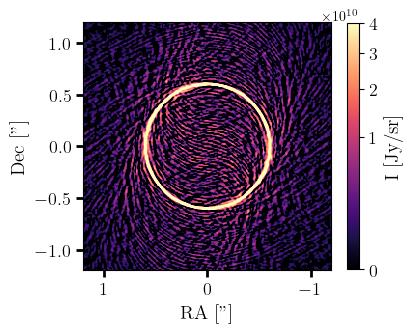

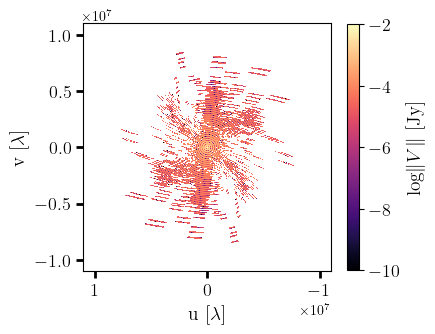

FWHM= 0.021955957568432084 +/- 8.01611186252027e-05 arcsec


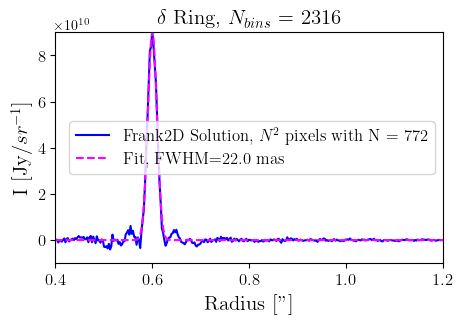

In [144]:
for frank2d2 in frank2d_objs:
    Plot_ = Plot(frank2d2, geom_f2d)
    Plot_.intensity(fig_size = 4, zoom=3, title= '', label_size=14)
    Plot_.visibility(fig_size = 4, kind = 'input',  title= r'')

    def gauss(r, sigma):
        return np.exp(-0.5*((r-rout/2.)/sigma)**2)

    # FWHM
    # deproject
    x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
    x_model, y_model = Plot_._x_model, Plot_._y_model

    I = frank2d2.intensity_model

    r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
    bins_f2d = 3*N
    r = np.linspace(r_.min(), r_.max(), bins_f2d)
    edges = Plot_.edges(r)

    r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)
    I_f2d = np.nan_to_num(I_f2d, nan=0)

    popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
    FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
    Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

    plt.close()
    plt.figure(figsize=(5,3))
    plt.plot(r_f2d, I_f2d, color='blue',label= r'Frank2D Solution, $N^{2}$ pixels with N = ' + str(N))
    plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), color='magenta', ls = '--', label='Fit, FWHM=%.1f mas'%(FWHM_frank2d*1000))
    plt.ylabel(r'I [Jy/$sr^{-1}$]', fontsize=15)
    plt.tick_params(axis='both', which='both', labelsize=12)
    plt.xlabel('Radius ["]', fontsize=15)
    plt.xlim(0.4, 1.2)
    plt.ylim(-1e10, 9e10)

    plt.title(r'$\delta$ Ring, $N_{bins}$ = '+ str(bins_f2d), fontsize=15)
    plt.legend(loc='best', fontsize = 12)
    
    resolutions.append(FWHM_frank2d)
    resolutions_error.append(Error_FWHM_f2d)

    print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

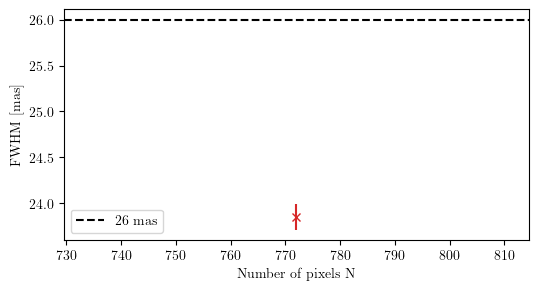

In [116]:
plt.figure(figsize=(6,3))
plt.errorbar(Ns, np.array(resolutions)*1000, yerr=np.array(resolutions_error)*1000, fmt='x:', color='C3')
plt.xlabel('Number of pixels N')
plt.axhline(y=26, color='k', linestyle='--', label='26 mas')
plt.ylabel('FWHM [mas]')
plt.legend()
plt.show()

### FWHM

In [114]:
# deproject
x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
x_model, y_model = Plot_._x_model, Plot_._y_model

In [115]:
I = Plot_._int_model

In [116]:
r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
bins_f2d = 3*N
r = np.linspace(r_.min(), r_.max(), bins_f2d)
edges = Plot_.edges(r)

In [117]:
r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)

In [118]:
I_f2d = np.nan_to_num(I_f2d, nan=0)

In [119]:
popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

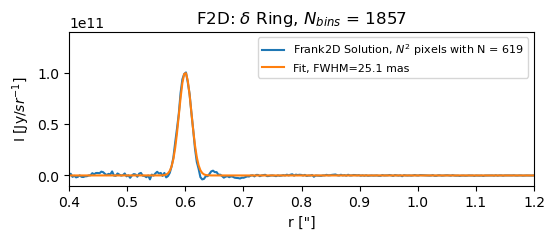

In [120]:
plt.close()
plt.figure(figsize=(6,2))
plt.plot(r_f2d, I_f2d, color='C0',label= r'Frank2D Solution, $N^{2}$ pixels with N = ' + str(N))
plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.4, rout)
plt.ylim(-1e10, 1.4e11)

plt.title(r'F2D: $\delta$ Ring, $N_{bins}$ = '+ str(bins_f2d))
plt.legend(loc='best', fontsize = 8)

In [121]:
print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

FWHM= 0.02512462865555891 +/- 9.290774739879294e-05 arcsec


### Frank1D

In [145]:
# load data||
u_f1d, v_f1d, Re_f1d, Imag_f1d, Weights_f1d = u, v, Re, Im, Weights
Vis_f1d = Re_f1d + Imag_f1d*1j

In [146]:
u_f1d_d, v_f1d_d, _ = geom_f2d.deproject(u_f1d, v_f1d)
dbaseline_f1d = np.hypot(u_f1d_d, v_f1d_d)
baseline_f1d = np.hypot(u_f1d, v_f1d)

In [147]:
baseline_ring_f1d = dbaseline_f1d

In [148]:
Re_ring = np.median(Re_f1d[np.where(baseline_ring_f1d<3e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring_f1d))

In [149]:
Imag_ring = np.zeros(len(Re_ring))
Vis_f1d = Re_ring + Imag_ring*1j

In [150]:
# Frank 1D parameters
n_pts = N//2
alpha = 1.2
w_smooth = 1e-2
r_out = Rmax

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, Vis_f1d, Weights_f1d)

In [151]:
r_f1d = sol.r
I_f1d = sol.mean

In [152]:
popt_frank1d, cov_frank1d = curve_fit(gauss, r_f1d, I_f1d/np.max(I_f1d), p0=[0.02])
FWHM_frank1d = popt_frank1d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [153]:
print ('FWHM=', FWHM_frank1d, '+/-', Error_FWHM_frank1d, 'arcsec')   

FWHM= 0.015190796938266807 +/- 0.000313145968156999 arcsec


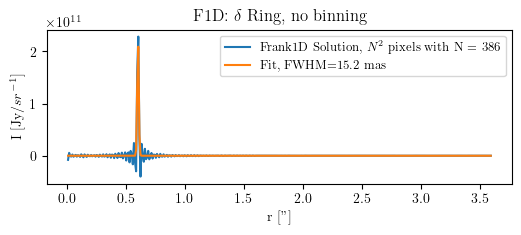

In [154]:
plt.close()
plt.figure(figsize=(6,2))
plt.plot(r_f1d, I_f1d, color='C0',label= r'Frank1D Solution, $N^{2}$ pixels with N = ' + str(n_pts))
plt.plot(r_f1d, gauss(r_f1d, *popt_frank1d)*np.max(sol.mean), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
#plt.xlim(0.5, 1.5)
plt.title(r'F1D: $\delta$ Ring, no binning')
plt.legend(loc='best', fontsize = 9)

### Comparison with F2D

NameError: name 'r_f2d' is not defined

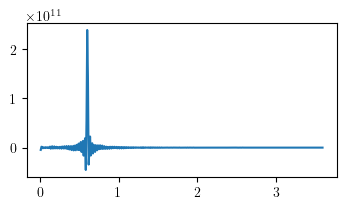

In [28]:
plt.close()
plt.figure(figsize=(4,2))
plt.plot(r_f1d, I_f1d,label= r'F2D, $N^{2}$ pixels (N = ' + str(N) + '), bins ='+  ' no bins' + ', FWHM = %.1f mas'%(FWHM_frank1d*1000))
plt.plot(r_f2d, I_f2d, label= r'F2D, $N^{2}$ pixels (N = ' + str(N) + '), bins ='+  str(bins_f2d) + ', FWHM = %.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(1, 1.8)
plt.ylim(-3e10, 2e11)
plt.title(r'$\delta$ Ring')
plt.legend(loc='best', fontsize = 6)

NameError: name 'r' is not defined

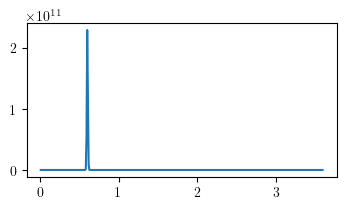

In [29]:
plt.close()
plt.figure(figsize=(4,2))
plt.plot(sol.r, gauss(sol.r, *popt_frank1d)*np.max(sol.mean), label='Fit F1D, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.plot(r, gauss(r, *popt_frank2d)*np.max(I), label='Fit F2D, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(1, 1.8)
plt.title('Gaussian fits')
plt.legend(loc='best', fontsize = 9)

### Convolve to the f2d beam

In [143]:
sigma_final = np.sqrt(FWHM_frank2d**2 - FWHM_frank1d**2)
sigma_final

0.01795838309477733

In [144]:
beam_1mm = {'bmaj':sigma_final, 'bmin':sigma_final, 'beam_pa':geom.PA}
convolved_frank1d = convolve_profile(r_f1d, I_f1d, geom.inc, geom.PA, beam_1mm)

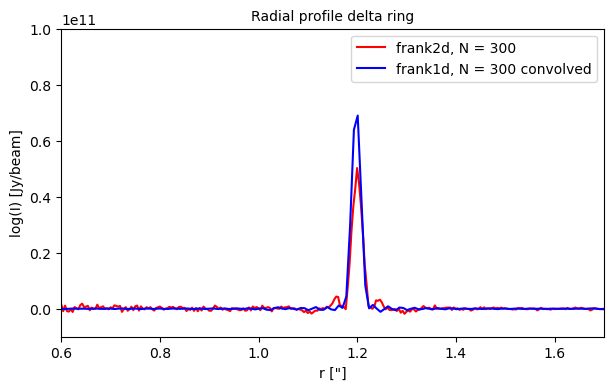

In [145]:
plt.figure(figsize=(7, 4))
plt.plot(r_f2d, I_f2d, "red", label=r'frank2d' + ', N = ' +str(n_pts))
plt.plot(r_f1d, convolved_frank1d, "blue", label=r'frank1d' + ', N = ' +str(N)+ ' convolved')
plt.title(r'Radial profile delta ring', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.xlim(0.6, 1.7)
plt.ylim(-1e10, 10e10)
plt.legend(fontsize=10)
plt.show()

In [69]:
popt_frank1d_conv, cov_frank1d_conv = curve_fit(gauss, r_f1d, convolved_frank1d/np.max(convolved_frank1d), p0=[0.009])
FWHM_frank1d_conv = popt_frank1d_conv[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d_conv = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [70]:
FWHM_frank1d_conv

0.0225764452262478

### Trying with real disk

In [11]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [12]:
N = 300
best = {'m': -1.011407337728121, 'c': 222.9257843669846, 'l': 46452.74921193543}

In [13]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.02  min |  1.37 seconds
--> time = 0.02  min |  1.41 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 3.5986215447871888
Final tolerance :  3.5986215447871888
.... iteration:  0
                        -> actual tol:  359862154.4787189 vs  3.5986215447871888
.... iteration:  1
                        -> actual tol:  16248311.289388938 vs  3.5986215447871888
.... iteration:  2
                        -> actual tol:  12793022.141465731 vs  3.5986215447871888
.... iteration:  3
                        -> actual tol:  17458649.174258534 vs  3.5986215447871888
.... iteration:  4
                        -> actual tol:  3767348.9717458216 vs  3.5986215447871888
.... iteration:  5
                        -> actual tol:  5315434.46853328 vs  3.5986215447871888
.... iteration:  6
                        -> actual tol:  1524640.4976162645 vs 

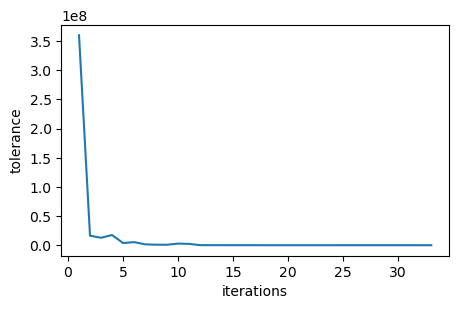

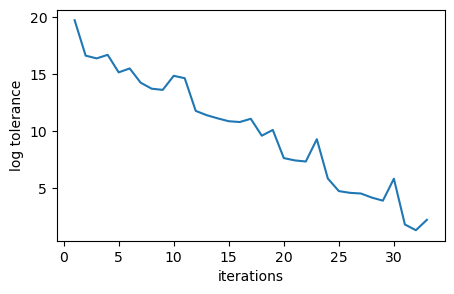

--> time = 0.02  min |  0.93 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
F2D model in 28.01 seconds.


In [15]:
start_time = time.time()


frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time):.2f} seconds.")

In [16]:
FWHM_frank2d = 0.022905863089907247
FWHM_frank1d = 0.011191120375380921

In [17]:
Plot_ = Plot(frank2d, geom)

In [18]:
from astropy.io import fits
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk

In [19]:
Plot_.set_fits_file(fits_name)

In [20]:
sol_f1d = frank2d.frank1d(uvtable, alpha=1.2, w_smooth=1e-3, n_pts=300, rout=rout, geom=geom)

Performing 1D Frank fit...

$\alpha$ =  1.2  and $w_{smooth}$ =  0.001

N =  300  and $R_{max}$ =  1.9


In [21]:
Plot_.set_f1d_solution(sol_f1d)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.022905863089907247 arcsec
-> Final beam to convolve with: 0.03059095415189107 x 0.028063616248335515 arcsec
FWHM for frank1d: 0.011191120375380921 arcsec
-> Final beam to convolve with: 0.0365409888284432 x 0.034452923614276196 arcsec


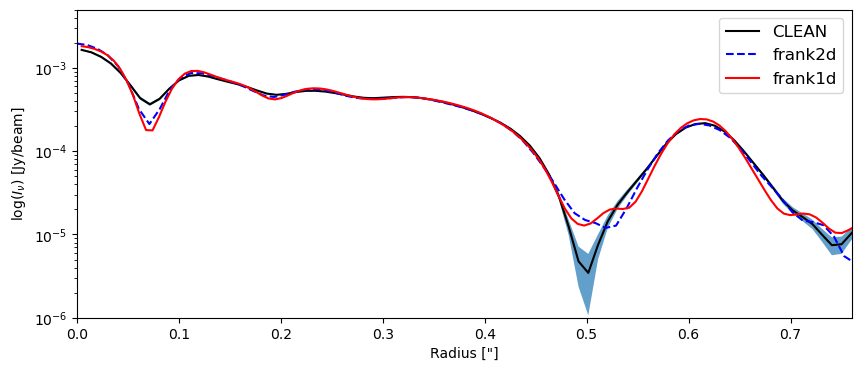

In [22]:
Plot_.intensity_profile(   clean = True, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d
                        )

UnboundLocalError: cannot access local variable 'y_lims_sr' where it is not associated with a value

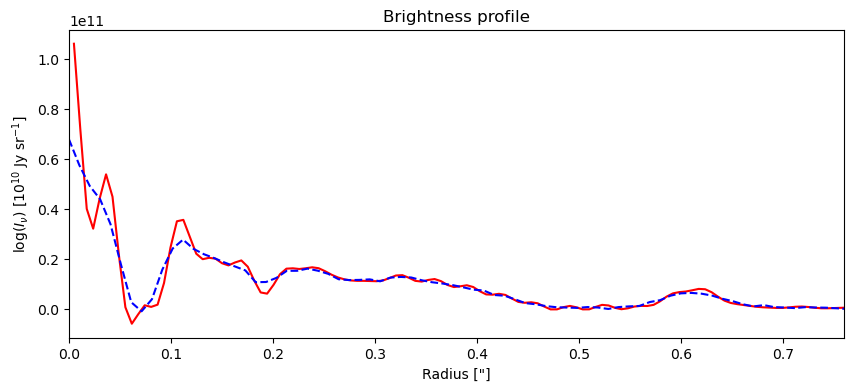

In [24]:
Plot_.intensity_profile(   clean = False, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d, 
                            y_lims = (1e8, 1e12)
                        )